# ETAPA 1 — EDA




In [1]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/rodrigolopez29/reviews/Reviews.csv


In [2]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split

df = pd.read_csv(
    "/kaggle/input/datasets/rodrigolopez29/reviews/Reviews.csv",
    engine="python",
    on_bad_lines="skip"
)

print("Shape original:", df.shape)
print(df.columns.tolist())

df = df[["Id", "ProductId", "Score", "Summary", "Text"]].copy()
df = df.dropna(subset=["Score", "Text"]).copy()

def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r"[^a-zA-Z\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

df["Text_clean"] = df["Text"].apply(limpiar_texto)
df["Summary_clean"] = df["Summary"].fillna("").apply(limpiar_texto)

df = df[df["Text_clean"].str.len() > 0].copy()

def convertir_sentimiento(score):
    if score <= 2:
        return "negative"
    elif score == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment"] = df["Score"].apply(convertir_sentimiento)

print("\nShape limpio:", df.shape)
print("\nDistribución de sentimiento:")
print(df["sentiment"].value_counts())

df[["Id", "ProductId", "Score", "sentiment", "Text_clean"]].head()

Shape original: (568454, 10)
['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']

Shape limpio: (568453, 8)

Distribución de sentimiento:
sentiment
positive    443776
negative     82037
neutral      42640
Name: count, dtype: int64


,Id,ProductId,Score,sentiment,Text_clean
0,1,B001E4KFG0,5,positive,i have bought several of the vitality canned d...
1,2,B00813GRG4,1,negative,product arrived labeled as jumbo salted peanut...
2,3,B000LQOCH0,4,positive,this is a confection that has been around a fe...
3,4,B000UA0QIQ,2,negative,if you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,5,positive,great taffy at a great price there was a wide ...


Columnas actuales:
['Id', 'ProductId', 'Score', 'Summary', 'Text', 'Text_clean', 'Summary_clean', 'sentiment']

Primeras 5 filas:
   Id   ProductId  Score sentiment  \
0   1  B001E4KFG0      5  positive   
1   2  B00813GRG4      1  negative   
2   3  B000LQOCH0      4  positive   
3   4  B000UA0QIQ      2  negative   
4   5  B006K2ZZ7K      5  positive   

                                          Text_clean  
0  i have bought several of the vitality canned d...  
1  product arrived labeled as jumbo salted peanut...  
2  this is a confection that has been around a fe...  
3  if you are looking for the secret ingredient i...  
4  great taffy at a great price there was a wide ...  

Valores nulos:
Id             0
ProductId      0
Score          0
Summary       27
Text           0
Text_clean     0
sentiment      0
dtype: int64

Distribucion de Score:
Score
1     52268
2     29769
3     42640
4     80655
5    363121
Name: count, dtype: int64

Distribucion de sentiment:
sentiment
positive 

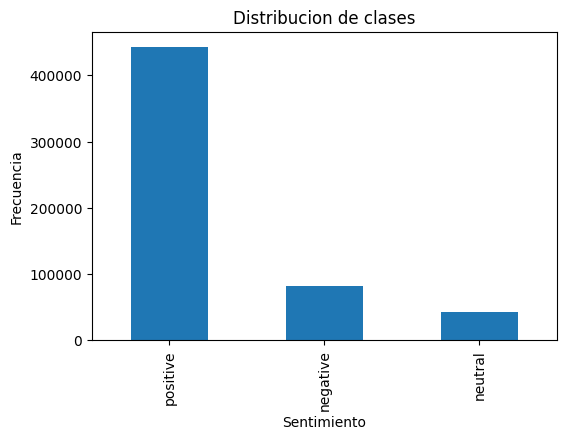

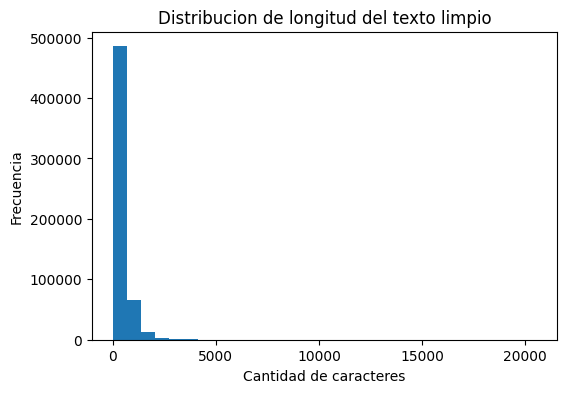

In [3]:
import matplotlib.pyplot as plt

print("Columnas actuales:")
print(df.columns.tolist())

print("\nPrimeras 5 filas:")
print(df[["Id", "ProductId", "Score", "sentiment", "Text_clean"]].head())

print("\nValores nulos:")
print(df[["Id", "ProductId", "Score", "Summary", "Text", "Text_clean", "sentiment"]].isnull().sum())

print("\nDistribucion de Score:")
print(df["Score"].value_counts().sort_index())

print("\nDistribucion de sentiment:")
print(df["sentiment"].value_counts())
print("\nDistribucion relativa de sentiment:")
print(df["sentiment"].value_counts(normalize=True))

df["text_len"] = df["Text_clean"].str.len()

print("\nResumen longitud de texto limpio:")
print(df["text_len"].describe())

plt.figure(figsize=(6,4))
df["sentiment"].value_counts().plot(kind="bar")
plt.title("Distribucion de clases")
plt.xlabel("Sentimiento")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(6,4))
df["text_len"].plot(kind="hist", bins=30)
plt.title("Distribucion de longitud del texto limpio")
plt.xlabel("Cantidad de caracteres")
plt.ylabel("Frecuencia")
plt.show()

## Análisis enriquecido del texto por clase

Antes de construir los modelos, queremos entender qué señales separan a las clases:
- **Longitud del texto por clase** (¿las reseñas negativas son más largas?)
- **Top unigramas / bigramas por clase** (¿qué palabras caracterizan cada sentimiento?)
- **Ejemplos representativos por clase**

Esto nos da intuición sobre qué puede capturar un MLP (bag-of-words) y qué requerirá arquitecturas
que entiendan contexto (CNN / Transformers).

Longitud del texto limpio por clase (estadísticas):
                 mean    50%    75%      max
sentiment                                   
negative   461.473481  331.0  553.0  11090.0
neutral    497.525235  359.0  628.0  20517.0
positive   401.642660  277.0  485.0  14813.0


<Figure size 800x500 with 0 Axes>

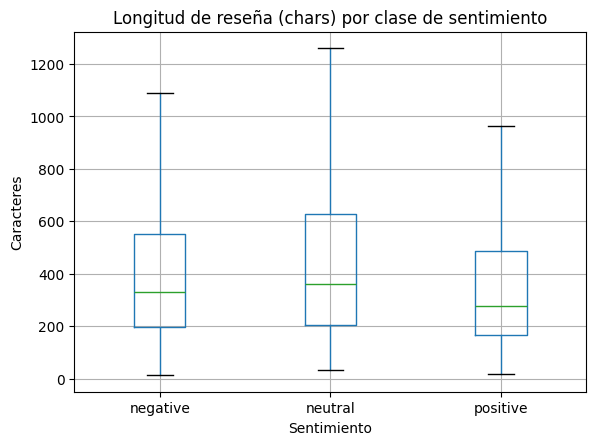

In [4]:
import matplotlib.pyplot as plt

# Longitud del texto limpio POR CLASE (en caracteres)
df["text_len"] = df["Text_clean"].str.len()

print("Longitud del texto limpio por clase (estadísticas):")
print(df.groupby("sentiment")["text_len"].describe()[["mean", "50%", "75%", "max"]])

# Boxplot de longitud por clase (limitando outliers para legibilidad)
plt.figure(figsize=(8, 5))
df.boxplot(column="text_len", by="sentiment", showfliers=False)
plt.title("Longitud de reseña (chars) por clase de sentimiento")
plt.suptitle("")
plt.ylabel("Caracteres")
plt.xlabel("Sentimiento")
plt.show()

In [5]:
from collections import Counter
import re

STOPWORDS = set("""
a about above after again against all am an and any are aren as at be because been before being below between
both but by can cant could couldnt did didnt do does doesnt doing dont down during each few for from further had
hadnt has hasnt have havent having he her here hers herself him himself his how i if in into is isnt it its itself
just ll me more most my myself no nor not now of off on once only or other our ours ourselves out over own s same
shan she should shouldnt so some such t than that the their theirs them themselves then there these they this
those through to too under until up ve very was wasnt we were werent what when where which while who whom why
will with wont would wouldnt you your yours yourself yourselves re m
""".split())

def top_ngrams(texts, n=1, k=15):
    counter = Counter()
    for txt in texts:
        tokens = [t for t in str(txt).split() if t and t not in STOPWORDS and len(t) > 2]
        if n == 1:
            counter.update(tokens)
        else:
            counter.update(zip(*[tokens[i:] for i in range(n)]))
    return counter.most_common(k)

print("=== Top 15 UNIGRAMAS por clase ===\n")
for clase in ["negative", "neutral", "positive"]:
    textos = df[df["sentiment"] == clase]["Text_clean"].sample(n=min(20000, (df['sentiment']==clase).sum()), random_state=42)
    print(f"\n-- {clase} --")
    for w, c in top_ngrams(textos, n=1, k=15):
        print(f"  {w:20s}  {c}")

print("\n\n=== Top 15 BIGRAMAS por clase ===\n")
for clase in ["negative", "neutral", "positive"]:
    textos = df[df["sentiment"] == clase]["Text_clean"].sample(n=min(20000, (df['sentiment']==clase).sum()), random_state=42)
    print(f"\n-- {clase} --")
    for bg, c in top_ngrams(textos, n=2, k=15):
        print(f"  {' '.join(bg):30s}  {c}")

=== Top 15 UNIGRAMAS por clase ===


-- negative --
  like                  11011
  product               8621
  taste                 7978
  one                   7022
  food                  5711
  coffee                5637
  good                  5340
  flavor                5109
  amazon                4212
  even                  4185
  tea                   4185
  don                   4064
  get                   3960
  buy                   3666
  really                3577

-- neutral --
  like                  12531
  taste                 9223
  good                  8790
  coffee                8591
  flavor                7753
  product               7509
  one                   6991
  tea                   4965
  much                  4849
  really                4707
  get                   4625
  don                   4537
  food                  4041
  little                3821
  better                3818

-- positive --
  like                  8226
  good          

In [6]:
# Ejemplos representativos por clase (longitud mediana y texto legible)
print("=== Ejemplos representativos por clase ===\n")
for clase in ["negative", "neutral", "positive"]:
    sub = df[df["sentiment"] == clase].copy()
    sub = sub[(sub["text_len"] > 100) & (sub["text_len"] < 400)]
    ejemplos = sub.sample(n=2, random_state=42)
    print(f"\n--- {clase.upper()} ---")
    for _, row in ejemplos.iterrows():
        print(f"  Score: {row['Score']}")
        print(f"  Texto: {row['Text_clean'][:300]}")
        print()

=== Ejemplos representativos por clase ===


--- NEGATIVE ---
  Score: 1
  Texto: so here i am thinking i m getting a great tasting cookie with splenda only to find out they use hydrogenated oils on top of that they use the worst kind of oil palm and palm kernel br br don t be fooled into thinking you are getting something heather because it has no sugar i would rather eat a tabl

  Score: 1
  Texto: they were all melted together br br there was no coushin or cooling pac in with them br br they were just rubber banned to a piece of cardboard


--- NEUTRAL ---
  Score: 3
  Texto: i buy this brand for my grandmother s cat i don t like that it includes so many additives and biproducts but her cat doesn t seem to care he actually seems to prefer it i prefer to buy organic for my cat but i m a bit of a snob when it comes to such things

  Score: 3
  Texto: i noticed nothing different about the flavor or lightness heaviness of this water it was water i tested the ph and it real only which is

In [7]:
from sklearn.model_selection import train_test_split

X = df["Text_clean"]
y = df["sentiment"]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,   # deja aprox 70/15/15
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("\nDistribucion y_train:")
print(y_train.value_counts(normalize=True))

print("\nDistribucion y_val:")
print(y_val.value_counts(normalize=True))

print("\nDistribucion y_test:")
print(y_test.value_counts(normalize=True))

train_df = pd.DataFrame({
    "Text_clean": X_train,
    "sentiment": y_train
}).reset_index(drop=True)

val_df = pd.DataFrame({
    "Text_clean": X_val,
    "sentiment": y_val
}).reset_index(drop=True)

test_df = pd.DataFrame({
    "Text_clean": X_test,
    "sentiment": y_test
}).reset_index(drop=True)

train_df.to_csv("/kaggle/working/train_etapa1.csv", index=False)
val_df.to_csv("/kaggle/working/val_etapa1.csv", index=False)
test_df.to_csv("/kaggle/working/test_etapa1.csv", index=False)

print("\nArchivos guardados:")
print("/kaggle/working/train_etapa1.csv")
print("/kaggle/working/val_etapa1.csv")
print("/kaggle/working/test_etapa1.csv")

print("\nVista rapida train_df:")
print(train_df.head())

Train: (397902,) (397902,)
Val: (85283,) (85283,)
Test: (85268,) (85268,)

Distribucion y_train:
sentiment
positive    0.780675
negative    0.144314
neutral     0.075011
Name: proportion, dtype: float64

Distribucion y_val:
sentiment
positive    0.780671
negative    0.144320
neutral     0.075009
Name: proportion, dtype: float64

Distribucion y_test:
sentiment
positive    0.780668
negative    0.144321
neutral     0.075011
Name: proportion, dtype: float64

Archivos guardados:
/kaggle/working/train_etapa1.csv
/kaggle/working/val_etapa1.csv
/kaggle/working/test_etapa1.csv

Vista rapida train_df:
                                          Text_clean sentiment
0  my dog loves this treat she loves the taste of...  positive
1  i bought the chicken meal and rice formula bec...  positive
2  very smooth tea can drink plain make a latte n...  positive
3  these have a very mild peanut butter flavor i ...  positive
4  i used this product several times along with t...  positive


In [8]:
# Desbalance de clases — análisis y estrategia
#
# Distribución observada (en proporción):
#   positive  ≈ 78%
#   negative  ≈ 14%
#   neutral   ≈ 8%
#
# Esto afecta fuertemente la evaluación: un clasificador trivial que siempre prediga "positive"
# ya lograría ~78% de accuracy, por lo que ACCURACY no es una métrica suficiente.
#
# Estrategia adoptada para las etapas siguientes:
#   1. Reportar SIEMPRE accuracy + F1 macro + classification_report (precision/recall/F1 por clase).
#      F1 MACRO penaliza el modelo si falla en las clases minoritarias, mientras que accuracy no.
#
#   2. En el modelo base (MLP) se aplica UNDERSAMPLING controlado de la clase positive
#      hasta 120k muestras, para reducir el sesgo del optimizador hacia la clase mayoritaria.
#
#   3. En la 1D-CNN se entrena sobre el dataset completo (sin undersampling) pero se analiza
#      la matriz de confusión para verificar que la clase neutral no colapsa.
#
#   4. En Transformers y T5 (etapas 3 y 4) el desbalance afecta menos porque son modelos
#      preentrenados que ya incorporan información de las tres polaridades.
#
# Nota sobre la limitación de la limpieza de texto:
# La función `limpiar_texto` elimina todo lo que no sea alfabético. Esto simplifica el vocabulario
# para TF-IDF/embeddings, pero tiene costo: se pierden números (p. ej. "5/5"), puntuación enfática
# (p. ej. "!!!") y negaciones con apóstrofe ("don't" -> "don t"). Las etapas que usan Transformers
# (RoBERTa, T5) trabajan sobre el texto ya tokenizado por su propio tokenizer, por lo que la pérdida
# en esas etapas es menor.

In [9]:
df["sentiment"].value_counts(normalize=True).to_csv(
    "/kaggle/working/distribucion_clases.csv"
)

Conclusiones de la etapa 1:
- El dataset fue limpiado y transformado a una variable objetivo multiclase: negative, neutral, positive.
- Se detectó desbalance de clases a favor de positive.
- Se generaron los conjuntos train, validation y test con estratificación.
- Los archivos exportados servirán como entrada del notebook de modelo base.